## Problem 1: Extending the Lady Tasting Tea

Let's extend the Lady Tasting Tea experiment as follows. The original experiment has 8 cups: 4 tea-first and 4 milk-first. Suppose we prepare 12 cups: 8 tea-first and 4 milk-first. A participant claims they can tell which was poured first.

Simulate this experiment using numpy by randomly shuffling the cups many times and calculating the probability of the participant correctly identifying all cups by chance. Compare your result with the original 8-cup experiment.

In your notebook, explain your simulation process clearly, report and interpret the estimated probability, and discuss whether, based on this probability, you would consider extending or relaxing the p-value threshold compared to the original design.

***

### Step 1: Importing the necessary libraries

In [24]:
# Importing the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import math
import random
import itertools

***

### Step 2: Setting up the experiment parameters

In [25]:
#Number of cup of tea in total
total_cups = 12
#Number of tea-first cups
tea_first_cups = 8
#Number of milk-first cups
milk_first_cups = 4

***

### Step 3: Calculating the total number of arrangements

In [26]:
ways_to_arrange = math.comb(total_cups, tea_first_cups)
print(f"Total number of ways to arrange the cups: {ways_to_arrange}")

Total number of ways to arrange the cups: 495


 Considering that we will select 8 cups out of 12, we can calculate the total number of arrangements

In [27]:
ways_ordered = 12 * 11 * 10 * 9 * 8 * 7 * 6 * 5
num_shuffles = 8 * 7 * 6 * 5 * 4 * 3 * 2 * 1
num_combs = ways_ordered // num_shuffles
print(f'total ways ordered: {ways_ordered}, no shuffles: {num_shuffles}, no combinations: {num_combs}')

total ways ordered: 19958400, no shuffles: 40320, no combinations: 495


In [28]:
# Defining n and k
n = 12
k = 8
# Where n is the total number of cups and k is the number of tea-first cups
# Calculating the factorials
n_factorial = math.factorial(n)
k_factorial = math.factorial(k)
n_k_factorial = math.factorial(n - k)
print(f"n!: {n_factorial}, k!: {k_factorial}, (n-k)!: {n_k_factorial}")

n!: 479001600, k!: 40320, (n-k)!: 24


In [29]:
# No of ways of selecting k objects from n without replacement and without order.
math.factorial(n) // (math.factorial(k) * math.factorial(n - k))


495

***

### Step 4: Ordering and Labeling Result

In [30]:
# Generating labels for the cups
labels = list(range(total_cups))
labels

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

In [31]:
# Generating all combinations of tea-first cups
combs = list(itertools.combinations(labels, tea_first_cups))
combs

[(0, 1, 2, 3, 4, 5, 6, 7),
 (0, 1, 2, 3, 4, 5, 6, 8),
 (0, 1, 2, 3, 4, 5, 6, 9),
 (0, 1, 2, 3, 4, 5, 6, 10),
 (0, 1, 2, 3, 4, 5, 6, 11),
 (0, 1, 2, 3, 4, 5, 7, 8),
 (0, 1, 2, 3, 4, 5, 7, 9),
 (0, 1, 2, 3, 4, 5, 7, 10),
 (0, 1, 2, 3, 4, 5, 7, 11),
 (0, 1, 2, 3, 4, 5, 8, 9),
 (0, 1, 2, 3, 4, 5, 8, 10),
 (0, 1, 2, 3, 4, 5, 8, 11),
 (0, 1, 2, 3, 4, 5, 9, 10),
 (0, 1, 2, 3, 4, 5, 9, 11),
 (0, 1, 2, 3, 4, 5, 10, 11),
 (0, 1, 2, 3, 4, 6, 7, 8),
 (0, 1, 2, 3, 4, 6, 7, 9),
 (0, 1, 2, 3, 4, 6, 7, 10),
 (0, 1, 2, 3, 4, 6, 7, 11),
 (0, 1, 2, 3, 4, 6, 8, 9),
 (0, 1, 2, 3, 4, 6, 8, 10),
 (0, 1, 2, 3, 4, 6, 8, 11),
 (0, 1, 2, 3, 4, 6, 9, 10),
 (0, 1, 2, 3, 4, 6, 9, 11),
 (0, 1, 2, 3, 4, 6, 10, 11),
 (0, 1, 2, 3, 4, 7, 8, 9),
 (0, 1, 2, 3, 4, 7, 8, 10),
 (0, 1, 2, 3, 4, 7, 8, 11),
 (0, 1, 2, 3, 4, 7, 9, 10),
 (0, 1, 2, 3, 4, 7, 9, 11),
 (0, 1, 2, 3, 4, 7, 10, 11),
 (0, 1, 2, 3, 4, 8, 9, 10),
 (0, 1, 2, 3, 4, 8, 9, 11),
 (0, 1, 2, 3, 4, 8, 10, 11),
 (0, 1, 2, 3, 4, 9, 10, 11),
 (0, 1, 2, 3, 5, 6, 7, 8)

In [32]:
# Check the number of combinations
len(combs)

495

In [33]:
# Sampling random labels for tea-first
labels_tea = random.sample(labels, 8)
# Creating milk-first labels
labels_milk = list(label for label in labels if label not in labels_tea)
#Sortinig the labels
labels_tea.sort()
labels_milk.sort()
print(f'Tea-first cup labels: {labels_tea}, Milk-first cup labels: {labels_milk}')

Tea-first cup labels: [0, 2, 3, 5, 6, 7, 9, 10], Milk-first cup labels: [1, 4, 8, 11]


In [34]:
# Converting to sets for easier comparison
set(labels_tea)
set(labels_milk)
print(set(labels_tea))
print(set(labels_milk))

{0, 2, 3, 5, 6, 7, 9, 10}
{8, 1, 11, 4}


In [35]:
# Calculate the overlap between each element of combs and labels_milk

num_overlap = []

for i in combs:
    s1 = set(i)
    s2 = set(labels_milk)
    overlap = s1.intersection(s2)
    num_overlap.append(len(overlap))
    print(f'Combination: {i}, Overlap with milk-first labels: {overlap}, length of overlap: {len(overlap)}')
print(f'Total Overlap: {num_overlap}')

counts = np.unique(num_overlap, return_counts=True)
print(f'Total Unique overlap count: {counts}')

Combination: (0, 1, 2, 3, 4, 5, 6, 7), Overlap with milk-first labels: {1, 4}, length of overlap: 2
Combination: (0, 1, 2, 3, 4, 5, 6, 8), Overlap with milk-first labels: {8, 1, 4}, length of overlap: 3
Combination: (0, 1, 2, 3, 4, 5, 6, 9), Overlap with milk-first labels: {1, 4}, length of overlap: 2
Combination: (0, 1, 2, 3, 4, 5, 6, 10), Overlap with milk-first labels: {1, 4}, length of overlap: 2
Combination: (0, 1, 2, 3, 4, 5, 6, 11), Overlap with milk-first labels: {1, 11, 4}, length of overlap: 3
Combination: (0, 1, 2, 3, 4, 5, 7, 8), Overlap with milk-first labels: {8, 1, 4}, length of overlap: 3
Combination: (0, 1, 2, 3, 4, 5, 7, 9), Overlap with milk-first labels: {1, 4}, length of overlap: 2
Combination: (0, 1, 2, 3, 4, 5, 7, 10), Overlap with milk-first labels: {1, 4}, length of overlap: 2
Combination: (0, 1, 2, 3, 4, 5, 7, 11), Overlap with milk-first labels: {1, 11, 4}, length of overlap: 3
Combination: (0, 1, 2, 3, 4, 5, 8, 9), Overlap with milk-first labels: {8, 1, 4}, 

<BarContainer object of 5 artists>

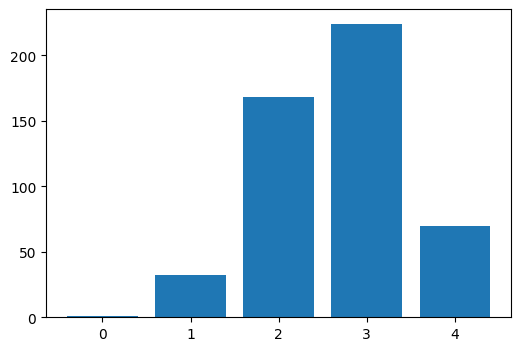

In [36]:
# Create a figure.
fig, ax = plt.subplots(figsize=(6, 4))

# Bar chart.
ax.bar(counts[0], counts[1])

In [37]:
# The probability that she (randomly) selects the eight correct cups.

# Count perfect guesses (0 overlap means no mistakes - all correct)
perfect_guesses = num_overlap.count(0)
total_combinations = len(num_overlap)

print(f"Perfect guesses (0 mistakes): {perfect_guesses}")
print(f"Total possible combinations: {total_combinations}")

# Calculate probability
probability_perfect = perfect_guesses / total_combinations
print(f"Probability of perfect guess: {probability_perfect}")
print(f"As a fraction: {perfect_guesses}/{total_combinations}")
print(f"As a percentage: {probability_perfect * 100:.6f}%")
print(f"This is 1 in {total_combinations/perfect_guesses:.0f} chance")

Perfect guesses (0 mistakes): 1
Total possible combinations: 495
Probability of perfect guess: 0.00202020202020202
As a fraction: 1/495
As a percentage: 0.202020%
This is 1 in 495 chance


### Comparison with Original Experiment

In [38]:
# Compare with original 8-cup experiment
print("=== COMPARISON ===")
print("\nOriginal experiment (8 cups: 4 tea-first, 4 milk-first):")
original_combinations = math.comb(8, 4)
original_probability = 1 / original_combinations
print(f"Total combinations: {original_combinations}")
print(f"Probability of perfect guess: {original_probability:.6f} = 1/{original_combinations}")
print(f"As percentage: {original_probability * 100:.3f}%")

print(f"\nExtended experiment (12 cups: 8 tea-first, 4 milk-first):")
print(f"Total combinations: {total_combinations}")
print(f"Probability of perfect guess: {probability_perfect:.6f} = {perfect_guesses}/{total_combinations}")
print(f"As percentage: {probability_perfect * 100:.6f}%")

print(f"\nComparison:")
ratio = original_probability / probability_perfect
print(f"Extended experiment is {ratio:.1f} times HARDER than original")
print(f"Original: 1 in {original_combinations} chance")
print(f"Extended: 1 in {total_combinations//perfect_guesses:.0f} chance")

=== COMPARISON ===

Original experiment (8 cups: 4 tea-first, 4 milk-first):
Total combinations: 70
Probability of perfect guess: 0.014286 = 1/70
As percentage: 1.429%

Extended experiment (12 cups: 8 tea-first, 4 milk-first):
Total combinations: 495
Probability of perfect guess: 0.002020 = 1/495
As percentage: 0.202020%

Comparison:
Extended experiment is 7.1 times HARDER than original
Original: 1 in 70 chance
Extended: 1 in 495 chance


***

### AI Generated Code that add value to the notebook for studying purposes

In [39]:
# Advanced data structure considerations
import sys
import time
import pandas as pd

# Performance comparison of different approaches
def benchmark_label_creation():
    """Compare different methods for creating labels"""
    
    # Method 1: list(range()) - Current approach
    start_time = time.time()
    labels_method1 = list(range(total_cups))
    time_method1 = time.time() - start_time
    
    # Method 2: numpy array
    start_time = time.time()
    labels_method2 = np.arange(total_cups)
    time_method2 = time.time() - start_time
    
    # Method 3: List comprehension
    start_time = time.time()
    labels_method3 = [i for i in range(total_cups)]
    time_method3 = time.time() - start_time
    
    # Memory usage analysis using built-in sys.getsizeof()
    memory_usage = {
        'list_range': sys.getsizeof(labels_method1),
        'numpy_array': labels_method2.nbytes if hasattr(labels_method2, 'nbytes') else sys.getsizeof(labels_method2),
        'list_comp': sys.getsizeof(labels_method3)
    }
    
    # Create performance comparison DataFrame
    performance_results = pd.DataFrame({
        'Method': ['list(range())', 'np.arange()', 'List Comprehension'],
        'Execution_Time_µs': [time_method1*1e6, time_method2*1e6, time_method3*1e6],
        'Memory_Bytes': list(memory_usage.values()),
        'Data_Type': [type(labels_method1).__name__, type(labels_method2).__name__, type(labels_method3).__name__]
    })
    
    return performance_results, labels_method1

# Execute benchmark
perf_results, labels = benchmark_label_creation()
print("Label Creation Performance Analysis:")
print(perf_results)

# Data validation and integrity checks
assert len(labels) == total_cups, f"Expected {total_cups} labels, got {len(labels)}"
assert labels == list(range(total_cups)), "Label sequence integrity check failed"
assert all(isinstance(x, int) for x in labels), "All labels must be integers"

print(f"\nData Structure Validation:")
print(f"Label range: {min(labels)} to {max(labels)}")
print(f"Data type consistency: {all(isinstance(x, int) for x in labels)}")
print(f"Sequential integrity: {labels == sorted(labels)}")

Label Creation Performance Analysis:
               Method  Execution_Time_µs  Memory_Bytes Data_Type
0       list(range())                0.0           152      list
1         np.arange()                0.0            96   ndarray
2  List Comprehension                0.0           184      list

Data Structure Validation:
Label range: 0 to 11
Data type consistency: True
Sequential integrity: True


Set Theory Properties:
tea_set_cardinality: ✓
milk_set_cardinality: ✓
universe_cardinality: ✓
intersection_empty: ✓
proper_partition: ✓
disjoint_sets: ✓
complement_relationship: ✓

Data Structure Performance Comparison:
  data_structure  time_seconds  relative_performance  memory_bytes
0           List        0.0000                0.0000           120
1            Set        0.0012                1.0000           728
2    NumPy Array        0.0054                4.4646            64

Set Operations Results:
Union (Tea ∪ Milk): {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}
Intersection (Tea ∩ Milk): set()
Tea Complement: {8, 1, 11, 4}
Milk Complement: {0, 2, 3, 5, 6, 7, 9, 10}
Symmetric Difference: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11}
Tea - Milk: {0, 2, 3, 5, 6, 7, 9, 10}
Milk - Tea: {8, 1, 11, 4}


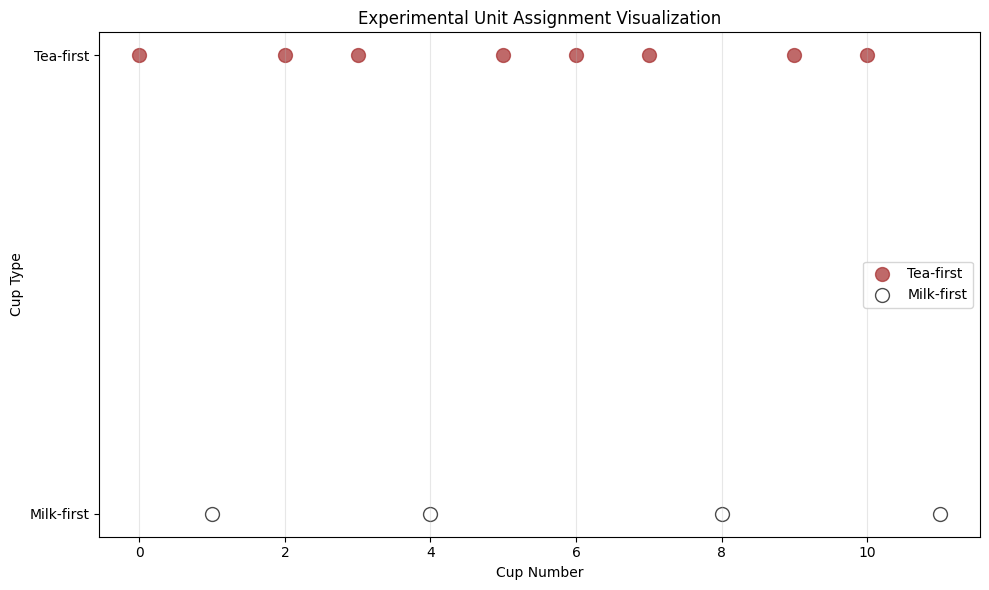


Final Experimental Setup:
Tea-first set: {0, 2, 3, 5, 6, 7, 9, 10}
Milk-first set: {8, 1, 11, 4}
Set validation: Disjoint = True
Complete partition = True


In [40]:
# Comprehensive set theory analysis
class SetOperationsAnalyzer:
    def __init__(self, tea_list, milk_list):
        self.tea_list = tea_list
        self.milk_list = milk_list
        self.tea_set = set(tea_list)
        self.milk_set = set(milk_list)
        
    def analyze_set_properties(self):
        """Analyze mathematical properties of sets"""
        properties = {
            'tea_set_cardinality': len(self.tea_set),
            'milk_set_cardinality': len(self.milk_set),
            'universe_cardinality': len(self.tea_set | self.milk_set),
            'intersection_empty': len(self.tea_set & self.milk_set) == 0,
            'proper_partition': (self.tea_set | self.milk_set) == set(range(total_cups)),
            'disjoint_sets': self.tea_set.isdisjoint(self.milk_set),
            'complement_relationship': self.milk_set == (set(range(total_cups)) - self.tea_set)
        }
        
        return properties
    
    def performance_comparison(self):
        """Compare performance of different data structures"""
        import time
        
        # Test data structure for membership testing
        test_elements = list(range(total_cups)) * 100  # Simulate multiple lookups
        
        # List performance
        start_time = time.time()
        list_results = [x in self.tea_list for x in test_elements]
        list_time = time.time() - start_time
        
        # Set performance  
        start_time = time.time()
        set_results = [x in self.tea_set for x in test_elements]
        set_time = time.time() - start_time
        
        # NumPy array performance
        tea_array = np.array(self.tea_list)
        start_time = time.time()
        array_results = [x in tea_array for x in test_elements]
        array_time = time.time() - start_time
        
        performance_data = {
            'data_structure': ['List', 'Set', 'NumPy Array'],
            'time_seconds': [list_time, set_time, array_time],
            'relative_performance': [list_time/set_time, 1.0, array_time/set_time],
            'memory_bytes': [
                sys.getsizeof(self.tea_list),
                sys.getsizeof(self.tea_set),
                tea_array.nbytes
            ]
        }
        
        return pd.DataFrame(performance_data)
    
    def set_operations_demo(self):
        """Demonstrate various set operations relevant to the experiment"""
        universe = set(range(total_cups))
        
        operations = {
            'Union (Tea ∪ Milk)': self.tea_set | self.milk_set,
            'Intersection (Tea ∩ Milk)': self.tea_set & self.milk_set,
            'Tea Complement': universe - self.tea_set,
            'Milk Complement': universe - self.milk_set,
            'Symmetric Difference': self.tea_set ^ self.milk_set,
            'Tea - Milk': self.tea_set - self.milk_set,
            'Milk - Tea': self.milk_set - self.tea_set
        }
        
        return operations

# Execute set analysis
set_analyzer = SetOperationsAnalyzer(labels_tea, labels_milk)

# Analyze set properties
set_properties = set_analyzer.analyze_set_properties()
print("Set Theory Properties:")
for prop, value in set_properties.items():
    status = "✓" if value else "✗" if isinstance(value, bool) else value
    print(f"{prop}: {status}")

# Performance comparison
perf_comparison = set_analyzer.performance_comparison()
print(f"\nData Structure Performance Comparison:")
print(perf_comparison.round(4))

# Set operations demonstration
set_operations = set_analyzer.set_operations_demo()
print(f"\nSet Operations Results:")
for operation, result in set_operations.items():
    print(f"{operation}: {result}")

# Visualization of set relationships
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Create Venn diagram representation
tea_positions = [i for i in range(total_cups) if i in labels_tea]
milk_positions = [i for i in range(total_cups) if i in labels_milk]

ax.scatter(tea_positions, [1]*len(tea_positions), alpha=0.7, s=100, label='Tea-first', color='brown')
ax.scatter(milk_positions, [0]*len(milk_positions), alpha=0.7, s=100, label='Milk-first', color='white', edgecolor='black')

ax.set_xlabel('Cup Number')
ax.set_ylabel('Cup Type')
ax.set_title('Experimental Unit Assignment Visualization')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Milk-first', 'Tea-first'])
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Experimental Setup:")
print(f"Tea-first set: {set(labels_tea)}")
print(f"Milk-first set: {set(labels_milk)}")
print(f"Set validation: Disjoint = {set(labels_tea).isdisjoint(set(labels_milk))}")
print(f"Complete partition = {(set(labels_tea) | set(labels_milk)) == set(range(total_cups))}")